# Mortgage Delinquency Risk Modeling

This notebook is the modeling stage of the project. The goal is to predict whether a loan is likely to become seriously delinquent within the next six months, using the cleaned and preprocessed loan-month panel from the earlier notebooks.

The target variable is `future_serious_dq_6m`. A value of 1 means the loan becomes 90 or more days delinquent within the next six months, while a value of 0 means it does not.

Since the positive class is rare, this is not a problem where accuracy alone tells the full story. A model could look accurate by mostly predicting that loans will not become seriously delinquent. For that reason, I will compare models using metrics that are more useful for imbalanced classification, especially precision, recall, F1 score, ROC-AUC, PR-AUC, and confusion matrices.

## 1. Imports and load the preprocessed data

I am starting from the saved outputs of the preprocessing notebook instead of rebuilding the preprocessing steps here. This keeps the modeling notebook focused on training, comparing, and evaluating models.

The files loaded below include the processed train and test feature matrices, the target values, the transformed feature names, the fitted preprocessing object, and the preprocessing summary.

In [1]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.sparse import load_npz

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [2]:
def find_project_root():
    candidates = [
        Path(".").resolve(),
        Path("..").resolve(),
        Path("../..").resolve()
    ]

    for candidate in candidates:
        if (candidate / "data" / "processed").exists():
            return candidate

    return Path("..").resolve()


PROJECT_ROOT = find_project_root()
DATASET_TAG = "2021q1_q2_sample10pct"
PREPROCESSING_DIR = PROJECT_ROOT / "data" / "processed" / f"preprocessing_outputs_{DATASET_TAG}"
MODEL_OUTPUT_DIR = PROJECT_ROOT / "models" / DATASET_TAG
REPORTS_DIR = PROJECT_ROOT / "reports" / "figures" / DATASET_TAG

MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Preprocessing folder:", PREPROCESSING_DIR)
print("Model output folder:", MODEL_OUTPUT_DIR)
print("Report figures folder:", REPORTS_DIR)


Project root: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk
Preprocessing folder: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\data\processed\preprocessing_outputs_2021q1_q2_sample10pct
Model output folder: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\models\2021q1_q2_sample10pct
Report figures folder: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\reports\figures\2021q1_q2_sample10pct


In [3]:
X_train = load_npz(PREPROCESSING_DIR / "X_train_processed.npz")
X_test = load_npz(PREPROCESSING_DIR / "X_test_processed.npz")

y_train = pd.read_csv(PREPROCESSING_DIR / "y_train.csv")["future_serious_dq_6m"]
y_test = pd.read_csv(PREPROCESSING_DIR / "y_test.csv")["future_serious_dq_6m"]

feature_names = pd.read_csv(PREPROCESSING_DIR / "feature_names.csv")
preprocessing_summary = pd.read_csv(PREPROCESSING_DIR / "preprocessing_summary.csv")
preprocessor = joblib.load(PREPROCESSING_DIR / "preprocessor.joblib")

In [4]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("Number of processed features:", len(feature_names))

display(preprocessing_summary)

X_train shape: (10059227, 172)
X_test shape: (2465712, 172)
y_train shape: (10059227,)
y_test shape: (2465712,)
Number of processed features: 172


,item,value
0,source_rows,13915701
1,labeled_rows,12524939
2,train_rows,10059227
3,test_rows,2465712
4,train_start_month,2021-01-01
5,train_end_month,2024-07-01
6,test_start_month,2024-08-01
7,test_end_month,2025-06-01
8,target,future_serious_dq_6m
9,train_target_rate,0.002366682847499117


## 2. Confirm the modeling setup

Before fitting models, I want to confirm the target balance in the training and test sets. This matters because serious delinquency is a rare event. If the target rate is very low, the model evaluation needs to focus on how well the model finds the risky loans, not just how often it is correct overall.

In [5]:
target_balance = pd.DataFrame({
    "split": ["train", "test"],
    "rows": [len(y_train), len(y_test)],
    "positive_rows": [int(y_train.sum()), int(y_test.sum())],
    "negative_rows": [int((y_train == 0).sum()), int((y_test == 0).sum())],
    "positive_rate": [y_train.mean(), y_test.mean()]
})

display(target_balance)

,split,rows,positive_rows,negative_rows,positive_rate
0,train,10059227,23807,10035420,0.002367
1,test,2465712,7385,2458327,0.002995


## 3. Baseline model

Before training real models, I want to create a simple baseline. This gives me something to compare the machine learning models against.

Because the target is very imbalanced, a baseline model that always predicts the majority class will have high accuracy, but it will not actually identify any risky loans. That is why I am using this section to show why accuracy is not enough for this problem.

For this project, the main baseline is a dummy classifier that predicts the most common class. If later models cannot improve on this baseline in useful metrics like recall, F1 score, ROC-AUC, and PR-AUC, then they are not adding much value.

In [6]:
def evaluate_classifier(model_name, model, X_train, y_train, X_test, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        train_scores = model.predict_proba(X_train)[:, 1]
        test_scores = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        train_scores = model.decision_function(X_train)
        test_scores = model.decision_function(X_test)
    else:
        train_scores = train_pred
        test_scores = test_pred

    metrics = {
        "model": model_name,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "train_precision": precision_score(y_train, train_pred, zero_division=0),
        "test_precision": precision_score(y_test, test_pred, zero_division=0),
        "train_recall": recall_score(y_train, train_pred, zero_division=0),
        "test_recall": recall_score(y_test, test_pred, zero_division=0),
        "train_f1": f1_score(y_train, train_pred, zero_division=0),
        "test_f1": f1_score(y_test, test_pred, zero_division=0),
        "train_roc_auc": roc_auc_score(y_train, train_scores),
        "test_roc_auc": roc_auc_score(y_test, test_scores),
        "train_pr_auc": average_precision_score(y_train, train_scores),
        "test_pr_auc": average_precision_score(y_test, test_scores)
    }

    return metrics

In [7]:
baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)

baseline_metrics = evaluate_classifier(
    "Dummy Classifier",
    baseline_model,
    X_train,
    y_train,
    X_test,
    y_test
)

baseline_results = pd.DataFrame([baseline_metrics])
display(baseline_results)

,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,train_roc_auc,test_roc_auc,train_pr_auc,test_pr_auc
0,Dummy Classifier,0.997633,0.997005,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.5,0.002367,0.002995


In [8]:
baseline_test_pred = baseline_model.predict(X_test)
baseline_cm = confusion_matrix(y_test, baseline_test_pred)

baseline_cm_df = pd.DataFrame(
    baseline_cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(baseline_cm_df)
print(classification_report(y_test, baseline_test_pred, zero_division=0))

,Predicted 0,Predicted 1
Actual 0,2458327,0
Actual 1,7385,0


              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2458327
           1       0.00      0.00      0.00      7385

    accuracy                           1.00   2465712
   macro avg       0.50      0.50      0.50   2465712
weighted avg       0.99      1.00      1.00   2465712



The baseline model confirms why this project cannot be judged by accuracy alone. It reached 99.70% accuracy on the test set, but it predicted every loan-month as not seriously delinquent. As a result, it missed all 7,385 rows in the test set that actually became seriously delinquent.

This makes the baseline useful, but only as a warning. A model for this project needs to do more than look accurate overall. It needs to identify some of the risky loans, even if that means accepting more false positives.

## 4. Logistic regression model

The first real model I am using is logistic regression. This is a good starting point because it is easy to interpret and gives a clear comparison against the dummy baseline.

Since the target is very imbalanced, I am using class weighting. This gives more weight to the rare delinquency cases during training. The goal is not just to maximize accuracy, but to give the model a better chance of finding loans that later become seriously delinquent.

In [9]:
log_reg_model = LogisticRegression(
    class_weight="balanced",
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

log_reg_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42,
                   solver='liblinear')

In [10]:
log_reg_metrics = evaluate_classifier(
    "Logistic Regression",
    log_reg_model,
    X_train,
    y_train,
    X_test,
    y_test
)

model_results = pd.concat(
    [
        baseline_results,
        pd.DataFrame([log_reg_metrics])
    ],
    ignore_index=True
)

display(model_results)

,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,train_roc_auc,test_roc_auc,train_pr_auc,test_pr_auc
0,Dummy Classifier,0.997633,0.997005,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.500000,0.500000,0.002367,0.002995
1,Logistic Regression,0.893795,0.929170,0.01782,0.033887,0.810728,0.82329,0.034873,0.065094,0.929859,0.942658,0.197658,0.213268


In [11]:
log_reg_test_pred = log_reg_model.predict(X_test)
log_reg_cm = confusion_matrix(y_test, log_reg_test_pred)

log_reg_cm_df = pd.DataFrame(
    log_reg_cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(log_reg_cm_df)
print(classification_report(y_test, log_reg_test_pred, zero_division=0))

,Predicted 0,Predicted 1
Actual 0,2284985,173342
Actual 1,1305,6080


              precision    recall  f1-score   support

           0       1.00      0.93      0.96   2458327
           1       0.03      0.82      0.07      7385

    accuracy                           0.93   2465712
   macro avg       0.52      0.88      0.51   2465712
weighted avg       1.00      0.93      0.96   2465712



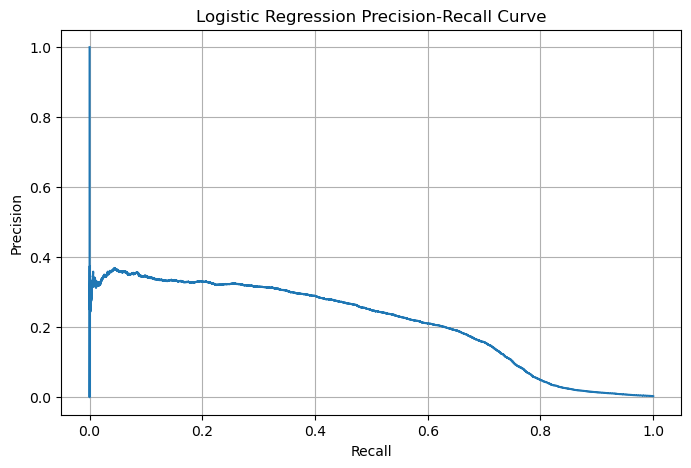

In [12]:
log_reg_scores = log_reg_model.predict_proba(X_test)[:, 1]

log_reg_precision, log_reg_recall, log_reg_thresholds = precision_recall_curve(
    y_test,
    log_reg_scores
)

plt.figure(figsize=(8, 5))
plt.plot(log_reg_recall, log_reg_precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Logistic Regression Precision-Recall Curve")
plt.grid(True)
plt.show()

Logistic regression is a major improvement over the dummy classifier. The dummy model missed every serious delinquency case, while logistic regression found 6,080 of the 7,385 serious delinquency rows in the test set.

The main tradeoff is precision. The model flagged about 179,000 loan-months as risky, but only 6,080 of those actually became seriously delinquent. That means the model is useful for ranking and early warning, but the default threshold is not a usable review list on its own.

The ROC-AUC and PR-AUC are also much better than the baseline. This suggests that the model is learning useful risk patterns from the loan and delinquency history features, not just guessing based on the majority class.

## 5. LightGBM boosted tree model

The next model is a boosted tree classifier. Boosting builds many small decision trees in sequence, where each new tree tries to improve on the mistakes of the earlier trees.

This type of model is a good fit for tabular data because it can capture nonlinear relationships and interactions between features. For this project, that matters because delinquency risk may depend on combinations of loan age, interest rate, payment history, prior delinquency behavior, loan purpose, occupancy type, and other fields.

I am using class imbalance handling again because serious delinquency is rare in the data. The model is evaluated using the same metrics as before so that the results can be compared fairly.

In [13]:
from lightgbm import LGBMClassifier

negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / positive_count

lgbm_model = LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 23807, number of negative: 10035420


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.325912 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3046
[LightGBM] [Info] Number of data points in the train set: 10059227, number of used features: 171
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.002367 -> initscore=-6.043896
[LightGBM] [Info] Start training from score -6.043896


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, min_child_samples=50,
               n_estimators=300, n_jobs=-1, objective='binary', random_state=42,
               scale_pos_weight=421.5323224261772, subsample=0.8)

In [14]:
lgbm_metrics = evaluate_classifier(
    "LightGBM",
    lgbm_model,
    X_train,
    y_train,
    X_test,
    y_test
)

model_results = pd.concat(
    [
        model_results,
        pd.DataFrame([lgbm_metrics])
    ],
    ignore_index=True
)

display(model_results)

,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,train_roc_auc,test_roc_auc,train_pr_auc,test_pr_auc
0,Dummy Classifier,0.997633,0.997005,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.500000,0.002367,0.002995
1,Logistic Regression,0.893795,0.929170,0.017820,0.033887,0.810728,0.823290,0.034873,0.065094,0.929859,0.942658,0.197658,0.213268
2,LightGBM,0.859547,0.876879,0.013511,0.020066,0.810224,0.838456,0.026579,0.039194,0.888931,0.900956,0.036637,0.069581


In [15]:
lgbm_test_pred = lgbm_model.predict(X_test)
lgbm_test_pred = lgbm_model.predict(X_test)

lgbm_cm = confusion_matrix(y_test, lgbm_test_pred)
lgbm_cm_df = pd.DataFrame(
    lgbm_cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(lgbm_cm_df)
print(classification_report(y_test, lgbm_test_pred, zero_division=0))

,Predicted 0,Predicted 1
Actual 0,2155938,302389
Actual 1,1193,6192


              precision    recall  f1-score   support

           0       1.00      0.88      0.93   2458327
           1       0.02      0.84      0.04      7385

    accuracy                           0.88   2465712
   macro avg       0.51      0.86      0.49   2465712
weighted avg       1.00      0.88      0.93   2465712



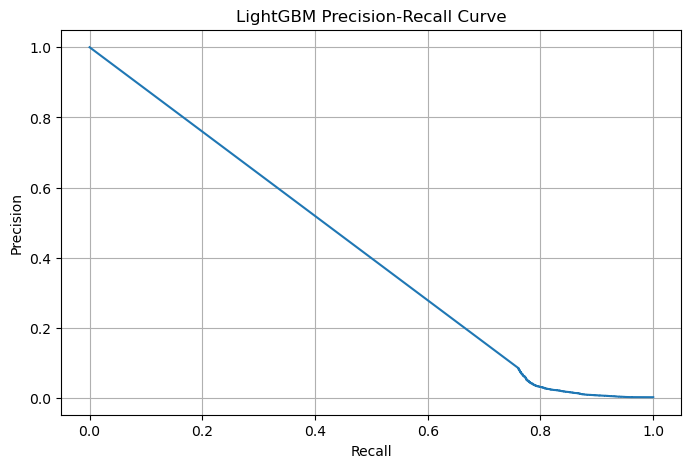

In [16]:
lgbm_scores = lgbm_model.predict_proba(X_test)[:, 1]

lgbm_precision, lgbm_recall, lgbm_thresholds = precision_recall_curve(
    y_test,
    lgbm_scores
)

plt.figure(figsize=(8, 5))
plt.plot(lgbm_recall, lgbm_precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("LightGBM Precision-Recall Curve")
plt.grid(True)
plt.show()

This result surprised me. On the earlier sample run, LightGBM with the full scale_pos_weight was the strongest ranking model. On the full panel it is clearly worse. Recall at the default threshold is high, finding 6,192 of the 7,385 cases, but it flags about 309,000 loan-months to get there, and its PR-AUC drops to about 0.07, far below logistic regression.

I think the full scale_pos_weight is too aggressive here. The positive class is only about 0.24% of training rows, so the weight comes out to roughly 420. With that much weight behind every positive row, the model pushes a huge share of the test set toward high scores and loses the clean ranking behavior it had on the smaller sample.

I am not dropping LightGBM based on this one configuration. The tuning section tests gentler settings, and the oversampling section changes the class balance in a different way. Both of those turn out to matter a lot for this model.

## 6. XGBoost boosted tree model

The next model is XGBoost. Like LightGBM, XGBoost is a boosted tree model that works well on structured tabular data. I am including it because boosted tree models often perform strongly on credit risk and delinquency-style problems.

The purpose of this section is not only to see whether XGBoost beats LightGBM, but also to check whether the strong LightGBM result is consistent across another tree boosting method.

In [17]:
from xgboost import XGBClassifier

negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / positive_count

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=50,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=50, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

In [18]:
xgb_metrics = evaluate_classifier(
    "XGBoost",
    xgb_model,
    X_train,
    y_train,
    X_test,
    y_test
)

model_results = pd.concat(
    [
        model_results,
        pd.DataFrame([xgb_metrics])
    ],
    ignore_index=True
)

display(model_results)

,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,train_roc_auc,test_roc_auc,train_pr_auc,test_pr_auc
0,Dummy Classifier,0.997633,0.997005,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.500000,0.002367,0.002995
1,Logistic Regression,0.893795,0.929170,0.017820,0.033887,0.810728,0.823290,0.034873,0.065094,0.929859,0.942658,0.197658,0.213268
2,LightGBM,0.859547,0.876879,0.013511,0.020066,0.810224,0.838456,0.026579,0.039194,0.888931,0.900956,0.036637,0.069581
3,XGBoost,0.896681,0.942048,0.018814,0.041130,0.833914,0.822343,0.036798,0.078342,0.946494,0.947248,0.320489,0.329854


In [19]:
xgb_test_pred = xgb_model.predict(X_test)
xgb_cm = confusion_matrix(y_test, xgb_test_pred)

xgb_cm_df = pd.DataFrame(
    xgb_cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(xgb_cm_df)
print(classification_report(y_test, xgb_test_pred, zero_division=0))

,Predicted 0,Predicted 1
Actual 0,2316747,141580
Actual 1,1312,6073


              precision    recall  f1-score   support

           0       1.00      0.94      0.97   2458327
           1       0.04      0.82      0.08      7385

    accuracy                           0.94   2465712
   macro avg       0.52      0.88      0.52   2465712
weighted avg       1.00      0.94      0.97   2465712



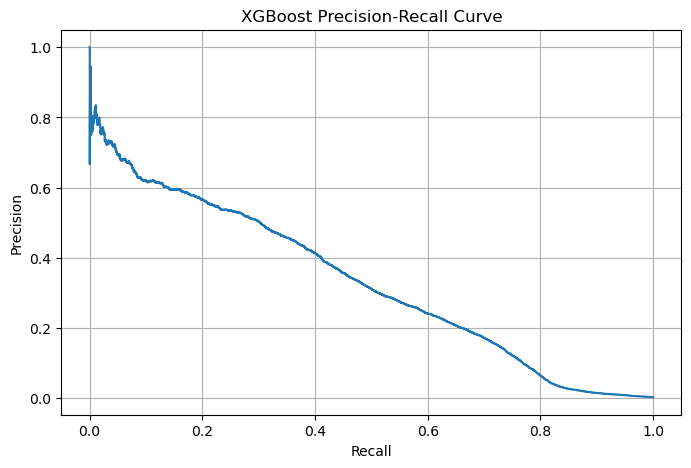

In [20]:
xgb_scores = xgb_model.predict_proba(X_test)[:, 1]

xgb_precision, xgb_recall, xgb_thresholds = precision_recall_curve(
    y_test,
    xgb_scores
)

plt.figure(figsize=(8, 5))
plt.plot(xgb_recall, xgb_precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost Precision-Recall Curve")
plt.grid(True)
plt.show()

XGBoost handles the full panel much better than LightGBM did with the same class weight. It finds 6,073 of the 7,385 serious delinquency rows, about 82% recall, and its PR-AUC of about 0.33 is the best of the standard models so far. It still flags around 148,000 loan-months at the default threshold, so precision is low, but the ranking quality is there.

The interesting part is that XGBoost and LightGBM received the same scale_pos_weight of roughly 420, and only XGBoost stayed stable. The main difference is tree shape. The depth-4 XGBoost trees are much more constrained than LightGBM's default 31-leaf trees, and that constraint seems to matter a lot when the class weight is this large.

## 7. Neural network model

The next model is a simple feedforward neural network. I am including it as a more complex model to compare against the linear and boosted tree models.

This is not an RNN or sequence model because the preprocessing notebook turned each loan-month into one modeling row. A feedforward neural network is a better fit for this version of the dataset because it learns from the tabular features directly.

The neural network may not beat the boosted tree models, but it is still useful to test because it can learn nonlinear patterns in the data.

In [21]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    batch_size=2048,
    learning_rate_init=0.001,
    max_iter=30,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=5,
    random_state=42,
    verbose=True
)

mlp_model.fit(X_train, y_train)

Iteration 1, loss = 0.01072269


Validation score: 0.997802


Iteration 2, loss = 0.00982926


Validation score: 0.997808


Iteration 3, loss = 0.00968555


...

Iteration 6, loss = 0.00933130


Validation score: 0.997837


Iteration 7, loss = 0.00922990


Validation score: 0.997835
Validation score did not improve more than tol=0.000100 for 5 consecutive epochs. Stopping.


MLPClassifier(batch_size=2048, early_stopping=True, hidden_layer_sizes=(64, 32),
              max_iter=30, n_iter_no_change=5, random_state=42, verbose=True)

In [22]:
mlp_metrics = evaluate_classifier(
    "Neural Network",
    mlp_model,
    X_train,
    y_train,
    X_test,
    y_test
)

model_results = pd.concat(
    [
        model_results,
        pd.DataFrame([mlp_metrics])
    ],
    ignore_index=True
)

display(model_results)

,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,train_roc_auc,test_roc_auc,train_pr_auc,test_pr_auc
0,Dummy Classifier,0.997633,0.997005,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.500000,0.002367,0.002995
1,Logistic Regression,0.893795,0.929170,0.017820,0.033887,0.810728,0.823290,0.034873,0.065094,0.929859,0.942658,0.197658,0.213268
2,LightGBM,0.859547,0.876879,0.013511,0.020066,0.810224,0.838456,0.026579,0.039194,0.888931,0.900956,0.036637,0.069581
3,XGBoost,0.896681,0.942048,0.018814,0.041130,0.833914,0.822343,0.036798,0.078342,0.946494,0.947248,0.320489,0.329854
4,Neural Network,0.997855,0.997102,0.624581,0.533576,0.234595,0.258226,0.341079,0.348024,0.953575,0.940716,0.341560,0.328794


In [23]:
mlp_test_pred = mlp_model.predict(X_test)
mlp_cm = confusion_matrix(y_test, mlp_test_pred)

mlp_cm_df = pd.DataFrame(
    mlp_cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(mlp_cm_df)
print(classification_report(y_test, mlp_test_pred, zero_division=0))

,Predicted 0,Predicted 1
Actual 0,2456660,1667
Actual 1,5478,1907


              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2458327
           1       0.53      0.26      0.35      7385

    accuracy                           1.00   2465712
   macro avg       0.77      0.63      0.67   2465712
weighted avg       1.00      1.00      1.00   2465712



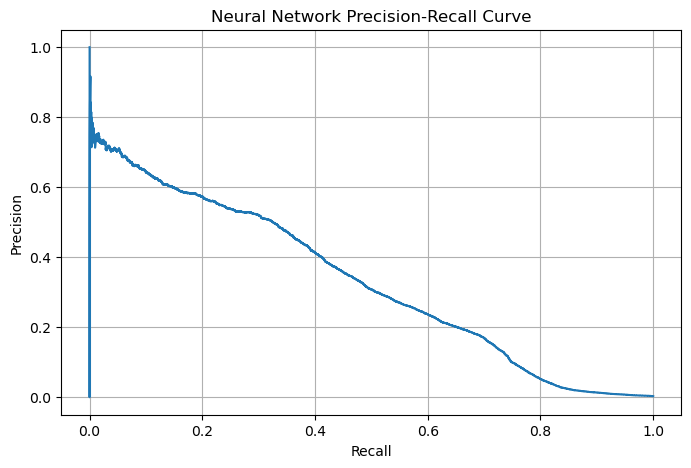

In [24]:
mlp_scores = mlp_model.predict_proba(X_test)[:, 1]

mlp_precision, mlp_recall, mlp_thresholds = precision_recall_curve(
    y_test,
    mlp_scores
)

plt.figure(figsize=(8, 5))
plt.plot(mlp_recall, mlp_precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Neural Network Precision-Recall Curve")
plt.grid(True)
plt.show()

The neural network behaves differently from the boosted tree models. It is much more conservative at the default threshold. It only flags 3,574 loan-months as risky, but 1,907 of those are actual serious delinquency cases. That gives it by far the best precision, about 53%, and the best default F1 score so far.

The tradeoff is recall. The neural network only finds 1,907 of the 7,385 serious delinquency rows, so it misses most of the risky loans. Its PR-AUC of about 0.33 sits right next to XGBoost, so as a ranking model it is competitive. It just sets a very high bar before calling anything risky at the 0.50 cutoff.

At this point XGBoost looks like the strongest ranking model and the neural network gives the cleanest default review list. That tension is exactly why the threshold tuning section matters later.

## 8. Model comparison

Now I am comparing all of the models together. Since the target is very imbalanced, I do not want to pick a final model based only on accuracy.

The most useful metrics here are recall, precision, F1 score, ROC-AUC, and PR-AUC. Recall tells me how many serious delinquency cases the model catches. Precision tells me how many flagged loans are actually risky. PR-AUC is especially important because it measures how well the model ranks rare positive cases.

In [25]:
comparison_columns = [
    "model",
    "test_accuracy",
    "test_precision",
    "test_recall",
    "test_f1",
    "test_roc_auc",
    "test_pr_auc"
]

model_comparison = model_results[comparison_columns].copy()
model_comparison = model_comparison.sort_values("test_pr_auc", ascending=False)

display(model_comparison)

,model,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc
3,XGBoost,0.942048,0.041130,0.822343,0.078342,0.947248,0.329854
4,Neural Network,0.997102,0.533576,0.258226,0.348024,0.940716,0.328794
1,Logistic Regression,0.929170,0.033887,0.823290,0.065094,0.942658,0.213268
2,LightGBM,0.876879,0.020066,0.838456,0.039194,0.900956,0.069581
0,Dummy Classifier,0.997005,0.000000,0.000000,0.000000,0.500000,0.002995


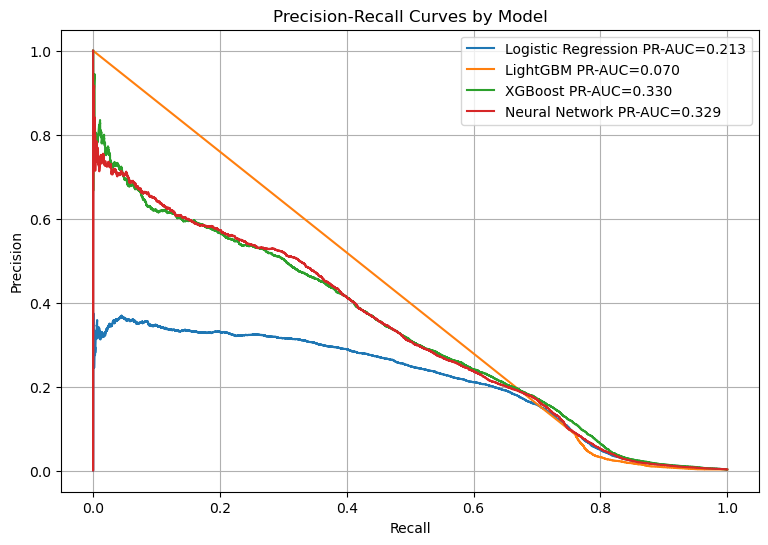

In [26]:
score_sets = {
    "Logistic Regression": log_reg_scores,
    "LightGBM": lgbm_scores,
    "XGBoost": xgb_scores,
    "Neural Network": mlp_scores
}

plt.figure(figsize=(9, 6))

for model_name, scores in score_sets.items():
    precision_values, recall_values, threshold_values = precision_recall_curve(y_test, scores)
    pr_auc_value = average_precision_score(y_test, scores)
    plt.plot(recall_values, precision_values, label=f"{model_name} PR-AUC={pr_auc_value:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves by Model")
plt.legend()
plt.grid(True)
plt.show()

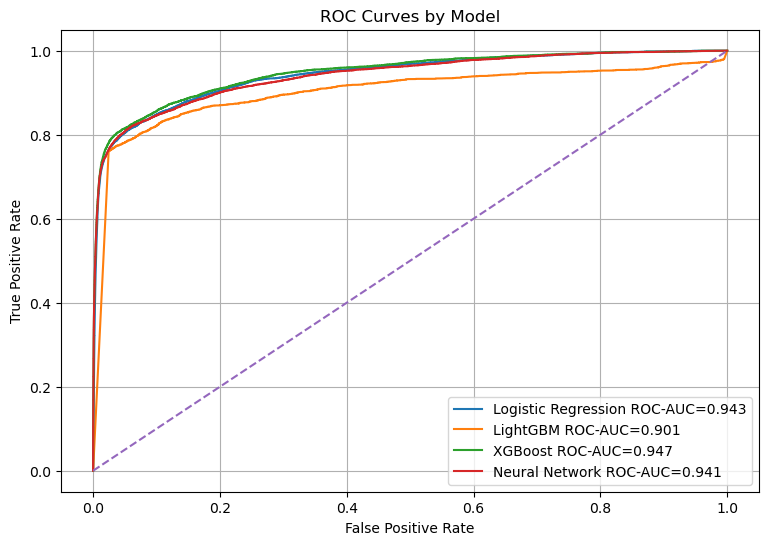

In [27]:
plt.figure(figsize=(9, 6))

for model_name, scores in score_sets.items():
    fpr_values, tpr_values, threshold_values = roc_curve(y_test, scores)
    roc_auc_value = roc_auc_score(y_test, scores)
    plt.plot(fpr_values, tpr_values, label=f"{model_name} ROC-AUC={roc_auc_value:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves by Model")
plt.legend()
plt.grid(True)
plt.show()

## 9. Hyperparameter tuning

After comparing the first set of models, LightGBM and XGBoost are the two models most worth tuning. Boosted trees are usually the strongest family for tabular risk data, and the weak untuned LightGBM result makes tuning feel necessary rather than optional, since the default configuration clearly did not handle the full class weight well.

I am not tuning every model equally because that would make the notebook slower without adding much value. Logistic regression is useful as an interpretable baseline, but its PR-AUC is well below the best boosted tree results. The neural network has strong precision and F1 at the default threshold, but its recall is low, so threshold tuning is more important for that model than a large architecture search.

For tuning, I am using the last part of the training set as a validation set. This keeps the process time-aware and avoids using the final test set to choose hyperparameters. Since the target is rare, the main tuning metric is PR-AUC.

In [28]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

validation_start = int(X_train.shape[0] * 0.8)

X_tune_train = X_train[:validation_start]
y_tune_train = y_train.iloc[:validation_start]

X_tune_valid = X_train[validation_start:]
y_tune_valid = y_train.iloc[validation_start:]

tune_negative_count = int((y_tune_train == 0).sum())
tune_positive_count = int((y_tune_train == 1).sum())
tune_scale_pos_weight = tune_negative_count / tune_positive_count

print("Tuning train shape:", X_tune_train.shape)
print("Validation shape:", X_tune_valid.shape)
print("Tuning train positive rate:", y_tune_train.mean())
print("Validation positive rate:", y_tune_valid.mean())
print("Base scale_pos_weight:", tune_scale_pos_weight)

Tuning train shape: (8047381, 172)
Validation shape: (2011846, 172)
Tuning train positive rate: 0.0023027367537339165
Validation positive rate: 0.0026224671272055615
Base scale_pos_weight: 433.26587879769033


In [29]:
def evaluate_validation_scores(y_true, scores, threshold=0.5):
    pred = (scores >= threshold).astype(int)

    return {
        "validation_precision": precision_score(y_true, pred, zero_division=0),
        "validation_recall": recall_score(y_true, pred, zero_division=0),
        "validation_f1": f1_score(y_true, pred, zero_division=0),
        "validation_roc_auc": roc_auc_score(y_true, scores),
        "validation_pr_auc": average_precision_score(y_true, scores)
    }

In [30]:
lgbm_candidates = [
    {"num_leaves": 31, "learning_rate": 0.05, "n_estimators": 300, "min_child_samples": 50, "reg_lambda": 1.0, "spw_multiplier": 1.0},
    {"num_leaves": 31, "learning_rate": 0.03, "n_estimators": 500, "min_child_samples": 50, "reg_lambda": 1.0, "spw_multiplier": 1.0},
    {"num_leaves": 63, "learning_rate": 0.03, "n_estimators": 500, "min_child_samples": 50, "reg_lambda": 1.0, "spw_multiplier": 1.0},
    {"num_leaves": 31, "learning_rate": 0.05, "n_estimators": 300, "min_child_samples": 100, "reg_lambda": 1.0, "spw_multiplier": 1.0},
    {"num_leaves": 63, "learning_rate": 0.05, "n_estimators": 300, "min_child_samples": 100, "reg_lambda": 3.0, "spw_multiplier": 1.0},
    {"num_leaves": 15, "learning_rate": 0.05, "n_estimators": 300, "min_child_samples": 100, "reg_lambda": 1.0, "spw_multiplier": 1.0},
    {"num_leaves": 31, "learning_rate": 0.05, "n_estimators": 300, "min_child_samples": 50, "reg_lambda": 1.0, "spw_multiplier": 0.75},
    {"num_leaves": 31, "learning_rate": 0.05, "n_estimators": 300, "min_child_samples": 50, "reg_lambda": 1.0, "spw_multiplier": 1.25}
]

xgb_candidates = [
    {"max_depth": 4, "learning_rate": 0.05, "n_estimators": 300, "min_child_weight": 50, "reg_lambda": 1.0, "spw_multiplier": 1.0},
    {"max_depth": 3, "learning_rate": 0.05, "n_estimators": 400, "min_child_weight": 50, "reg_lambda": 1.0, "spw_multiplier": 1.0},
    {"max_depth": 4, "learning_rate": 0.03, "n_estimators": 500, "min_child_weight": 50, "reg_lambda": 1.0, "spw_multiplier": 1.0},
    {"max_depth": 5, "learning_rate": 0.03, "n_estimators": 500, "min_child_weight": 100, "reg_lambda": 3.0, "spw_multiplier": 1.0},
    {"max_depth": 3, "learning_rate": 0.05, "n_estimators": 300, "min_child_weight": 100, "reg_lambda": 1.0, "spw_multiplier": 1.0},
    {"max_depth": 4, "learning_rate": 0.05, "n_estimators": 300, "min_child_weight": 100, "reg_lambda": 5.0, "spw_multiplier": 1.0},
    {"max_depth": 4, "learning_rate": 0.05, "n_estimators": 300, "min_child_weight": 50, "reg_lambda": 1.0, "spw_multiplier": 0.75},
    {"max_depth": 4, "learning_rate": 0.05, "n_estimators": 300, "min_child_weight": 50, "reg_lambda": 1.0, "spw_multiplier": 1.25}
]

In [31]:
tuning_results = []

for candidate_number, params in enumerate(lgbm_candidates, start=1):
    model = LGBMClassifier(
        objective="binary",
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        num_leaves=params["num_leaves"],
        min_child_samples=params["min_child_samples"],
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=params["reg_lambda"],
        scale_pos_weight=tune_scale_pos_weight * params["spw_multiplier"],
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    model.fit(X_tune_train, y_tune_train)
    valid_scores = model.predict_proba(X_tune_valid)[:, 1]
    metrics = evaluate_validation_scores(y_tune_valid, valid_scores)

    tuning_results.append({
        "model": "LightGBM",
        "candidate": candidate_number,
        **params,
        **metrics
    })

for candidate_number, params in enumerate(xgb_candidates, start=1):
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        min_child_weight=params["min_child_weight"],
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=params["reg_lambda"],
        scale_pos_weight=tune_scale_pos_weight * params["spw_multiplier"],
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )

    model.fit(X_tune_train, y_tune_train)
    valid_scores = model.predict_proba(X_tune_valid)[:, 1]
    metrics = evaluate_validation_scores(y_tune_valid, valid_scores)

    tuning_results.append({
        "model": "XGBoost",
        "candidate": candidate_number,
        **params,
        **metrics
    })

tuning_results = pd.DataFrame(tuning_results)
tuning_results = tuning_results.sort_values("validation_pr_auc", ascending=False)

display(tuning_results)

,model,candidate,num_leaves,learning_rate,n_estimators,min_child_samples,reg_lambda,spw_multiplier,validation_precision,validation_recall,validation_f1,validation_roc_auc,validation_pr_auc,max_depth,min_child_weight
11,XGBoost,4,NaN,0.03,500,NaN,3.0,1.00,0.045376,0.810462,0.085941,0.952181,0.344359,5.0,100.0
8,XGBoost,1,NaN,0.05,300,NaN,1.0,1.00,0.037994,0.827142,0.072650,0.952327,0.335084,4.0,50.0
10,XGBoost,3,NaN,0.03,500,NaN,1.0,1.00,0.037933,0.823541,0.072525,0.952302,0.334153,4.0,50.0
14,XGBoost,7,NaN,0.05,300,NaN,1.0,0.75,0.054501,0.796437,0.102021,0.952509,0.332788,4.0,50.0
15,XGBoost,8,NaN,0.05,300,NaN,1.0,1.25,0.028056,0.848180,0.054315,0.952143,0.331256,4.0,50.0
13,XGBoost,6,NaN,0.05,300,NaN,5.0,1.00,0.037182,0.825625,0.071160,0.952383,0.330156,4.0,100.0
12,XGBoost,5,NaN,0.05,300,NaN,1.0,1.00,0.036812,0.828848,0.070492,0.952248,0.323747,3.0,100.0
9,XGBoost,2,NaN,0.05,400,NaN,1.0,1.00,0.036823,0.830743,0.070521,0.952511,0.322561,3.0,50.0
1,LightGBM,2,31.0,0.03,500,50.0,1.0,1.00,0.047111,0.799469,0.088979,0.947216,0.319602,NaN,NaN
2,LightGBM,3,63.0,0.03,500,50.0,1.0,1.00,0.060295,0.782032,0.111958,0.937061,0.303543,NaN,NaN


In [32]:
best_lgbm_candidate = tuning_results[tuning_results["model"] == "LightGBM"].iloc[0]
best_xgb_candidate = tuning_results[tuning_results["model"] == "XGBoost"].iloc[0]

display(best_lgbm_candidate)
display(best_xgb_candidate)

model                   LightGBM
candidate                      2
num_leaves                  31.0
learning_rate               0.03
n_estimators                 500
min_child_samples           50.0
reg_lambda                   1.0
spw_multiplier               1.0
validation_precision    0.047111
validation_recall       0.799469
validation_f1           0.088979
validation_roc_auc      0.947216
validation_pr_auc       0.319602
max_depth                    NaN
min_child_weight             NaN
Name: 1, dtype: object

model                    XGBoost
candidate                      4
num_leaves                   NaN
learning_rate               0.03
n_estimators                 500
min_child_samples            NaN
reg_lambda                   3.0
spw_multiplier               1.0
validation_precision    0.045376
validation_recall       0.810462
validation_f1           0.085941
validation_roc_auc      0.952181
validation_pr_auc       0.344359
max_depth                    5.0
min_child_weight           100.0
Name: 11, dtype: object

The tuning results flipped my expectation from the earlier sample run. Every XGBoost candidate beat every LightGBM candidate on validation PR-AUC. The best XGBoost setting used deeper trees with more regularization, with max_depth 5, learning rate 0.03, 500 trees, and reg_lambda 3. The best LightGBM setting kept 31 leaves but slowed the learning rate to 0.03 with 500 trees.

The common theme is that both models prefer a lower learning rate with more trees on this much larger panel. LightGBM in particular recovered a lot compared with its default configuration, which supports the idea that the settings were the problem, not the model itself.

The next step is to retrain the best LightGBM and best XGBoost settings on the full training set, then evaluate both on the final test set.

In [33]:
best_xgb_candidate = tuning_results[tuning_results["model"] == "XGBoost"].iloc[0]

display(best_lgbm_candidate)
display(best_xgb_candidate)

model                   LightGBM
candidate                      2
num_leaves                  31.0
learning_rate               0.03
n_estimators                 500
min_child_samples           50.0
reg_lambda                   1.0
spw_multiplier               1.0
validation_precision    0.047111
validation_recall       0.799469
validation_f1           0.088979
validation_roc_auc      0.947216
validation_pr_auc       0.319602
max_depth                    NaN
min_child_weight             NaN
Name: 1, dtype: object

model                    XGBoost
candidate                      4
num_leaves                   NaN
learning_rate               0.03
n_estimators                 500
min_child_samples            NaN
reg_lambda                   3.0
spw_multiplier               1.0
validation_precision    0.045376
validation_recall       0.810462
validation_f1           0.085941
validation_roc_auc      0.952181
validation_pr_auc       0.344359
max_depth                    5.0
min_child_weight           100.0
Name: 11, dtype: object

In [34]:
final_negative_count = int((y_train == 0).sum())
final_positive_count = int((y_train == 1).sum())
final_scale_pos_weight = final_negative_count / final_positive_count

tuned_lgbm_model = LGBMClassifier(
    objective="binary",
    n_estimators=int(best_lgbm_candidate["n_estimators"]),
    learning_rate=float(best_lgbm_candidate["learning_rate"]),
    num_leaves=int(best_lgbm_candidate["num_leaves"]),
    min_child_samples=int(best_lgbm_candidate["min_child_samples"]),
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=float(best_lgbm_candidate["reg_lambda"]),
    scale_pos_weight=final_scale_pos_weight * float(best_lgbm_candidate["spw_multiplier"]),
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

tuned_lgbm_model.fit(X_train, y_train)

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.03, min_child_samples=50,
               n_estimators=500, n_jobs=-1, objective='binary', random_state=42,
               reg_lambda=1.0, scale_pos_weight=421.5323224261772,
               subsample=0.8, verbosity=-1)

In [35]:
tuned_xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=int(best_xgb_candidate["n_estimators"]),
    learning_rate=float(best_xgb_candidate["learning_rate"]),
    max_depth=int(best_xgb_candidate["max_depth"]),
    min_child_weight=float(best_xgb_candidate["min_child_weight"]),
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=float(best_xgb_candidate["reg_lambda"]),
    scale_pos_weight=final_scale_pos_weight * float(best_xgb_candidate["spw_multiplier"]),
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

tuned_xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=100.0, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

In [36]:
tuned_lgbm_metrics = evaluate_classifier(
    "Tuned LightGBM",
    tuned_lgbm_model,
    X_train,
    y_train,
    X_test,
    y_test
)

tuned_xgb_metrics = evaluate_classifier(
    "Tuned XGBoost",
    tuned_xgb_model,
    X_train,
    y_train,
    X_test,
    y_test
)

model_results = model_results[
    ~model_results["model"].isin(["Tuned LightGBM", "Tuned XGBoost"])
].copy()

model_results = pd.concat(
    [
        model_results,
        pd.DataFrame([tuned_lgbm_metrics, tuned_xgb_metrics])
    ],
    ignore_index=True
)

display(model_results)

,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,train_roc_auc,test_roc_auc,train_pr_auc,test_pr_auc
0,Dummy Classifier,0.997633,0.997005,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.500000,0.002367,0.002995
1,Logistic Regression,0.893795,0.929170,0.017820,0.033887,0.810728,0.823290,0.034873,0.065094,0.929859,0.942658,0.197658,0.213268
2,LightGBM,0.859547,0.876879,0.013511,0.020066,0.810224,0.838456,0.026579,0.039194,0.888931,0.900956,0.036637,0.069581
3,XGBoost,0.896681,0.942048,0.018814,0.041130,0.833914,0.822343,0.036798,0.078342,0.946494,0.947248,0.320489,0.329854
4,Neural Network,0.997855,0.997102,0.624581,0.533576,0.234595,0.258226,0.341079,0.348024,0.953575,0.940716,0.341560,0.328794
5,Tuned LightGBM,0.898691,0.924858,0.020244,0.032173,0.882051,0.828301,0.039580,0.061941,0.967135,0.936616,0.337215,0.326187
6,Tuned XGBoost,0.904922,0.945279,0.020777,0.043522,0.849204,0.823290,0.040562,0.082673,0.956202,0.947820,0.339173,0.337111


In [37]:
tuned_lgbm_test_pred = tuned_lgbm_model.predict(X_test)
tuned_lgbm_cm = confusion_matrix(y_test, tuned_lgbm_test_pred)

tuned_lgbm_cm_df = pd.DataFrame(
    tuned_lgbm_cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(tuned_lgbm_cm_df)
print(classification_report(y_test, tuned_lgbm_test_pred, zero_division=0))

,Predicted 0,Predicted 1
Actual 0,2274317,184010
Actual 1,1268,6117


              precision    recall  f1-score   support

           0       1.00      0.93      0.96   2458327
           1       0.03      0.83      0.06      7385

    accuracy                           0.92   2465712
   macro avg       0.52      0.88      0.51   2465712
weighted avg       1.00      0.92      0.96   2465712



In [38]:
tuned_xgb_test_pred = tuned_xgb_model.predict(X_test)
tuned_xgb_cm = confusion_matrix(y_test, tuned_xgb_test_pred)

tuned_xgb_cm_df = pd.DataFrame(
    tuned_xgb_cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(tuned_xgb_cm_df)
print(classification_report(y_test, tuned_xgb_test_pred, zero_division=0))

,Predicted 0,Predicted 1
Actual 0,2324706,133621
Actual 1,1305,6080


              precision    recall  f1-score   support

           0       1.00      0.95      0.97   2458327
           1       0.04      0.82      0.08      7385

    accuracy                           0.95   2465712
   macro avg       0.52      0.88      0.53   2465712
weighted avg       1.00      0.95      0.97   2465712



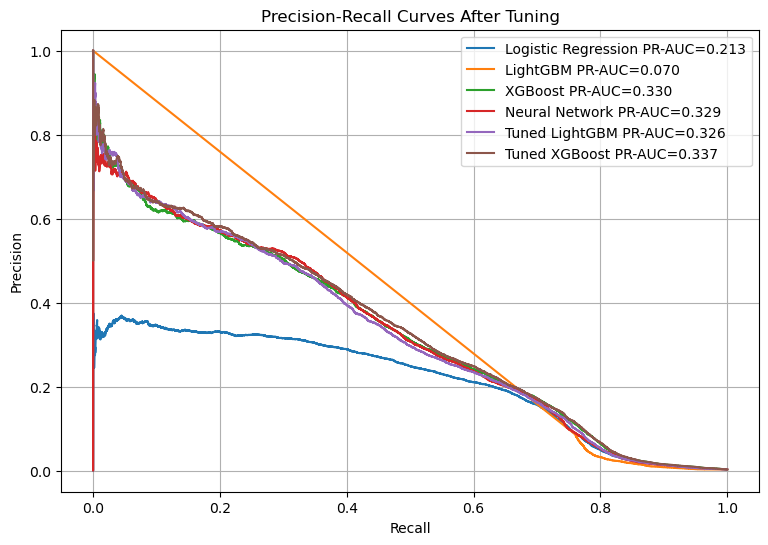

In [39]:
tuned_lgbm_scores = tuned_lgbm_model.predict_proba(X_test)[:, 1]
tuned_xgb_scores = tuned_xgb_model.predict_proba(X_test)[:, 1]

updated_score_sets = {
    "Logistic Regression": log_reg_scores,
    "LightGBM": lgbm_scores,
    "XGBoost": xgb_scores,
    "Neural Network": mlp_scores,
    "Tuned LightGBM": tuned_lgbm_scores,
    "Tuned XGBoost": tuned_xgb_scores
}

plt.figure(figsize=(9, 6))

for model_name, scores in updated_score_sets.items():
    precision_values, recall_values, threshold_values = precision_recall_curve(y_test, scores)
    pr_auc_value = average_precision_score(y_test, scores)
    plt.plot(recall_values, precision_values, label=f"{model_name} PR-AUC={pr_auc_value:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves After Tuning")
plt.legend()
plt.grid(True)
plt.show()

On the test set, Tuned XGBoost is the best ranking model so far with a PR-AUC of about 0.337, just ahead of the untuned XGBoost. Tuned LightGBM came back from its weak default result to a PR-AUC of about 0.326, which confirms that the original problem was the configuration rather than the algorithm.

Both tuned models still flag far too many loan-months at the 0.50 threshold to be a practical review list. Their value is in the ranking, not in the default cutoff.

Because of that, I do not want to choose the final model only from the default 0.50 threshold. The next step is threshold tuning. This will show how the stronger ranking models perform when the cutoff is adjusted for different business goals.

## 10. Threshold tuning

The models so far have been evaluated at their default classification threshold. For most binary classifiers, that means a loan is predicted as risky if its predicted probability is at least 0.50.

That default cutoff is not always the right choice for an imbalanced risk problem. A lower threshold usually catches more serious delinquency cases but creates more false positives. A higher threshold usually improves precision but misses more risky loans.

In this section, I compare several thresholds for the strongest candidate models. This helps show how the model could be used depending on the lender's goal.

In [40]:
def evaluate_thresholds(model_name, y_true, scores, thresholds):
    rows = []

    for threshold in thresholds:
        pred = (scores >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()

        rows.append({
            "model": model_name,
            "threshold": threshold,
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred, zero_division=0),
            "true_positives": tp,
            "false_positives": fp,
            "false_negatives": fn,
            "true_negatives": tn,
            "flagged_loans": tp + fp,
            "flag_rate": (tp + fp) / len(y_true)
        })

    return pd.DataFrame(rows)

In [41]:
thresholds_to_check = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.60,
    0.70,
    0.80
]

threshold_results = pd.concat(
    [
        evaluate_thresholds("LightGBM", y_test, lgbm_scores, thresholds_to_check),
        evaluate_thresholds("Tuned LightGBM", y_test, tuned_lgbm_scores, thresholds_to_check),
        evaluate_thresholds("Neural Network", y_test, mlp_scores, thresholds_to_check)
    ],
    ignore_index=True
)

display(threshold_results)

,model,threshold,precision,recall,f1,true_positives,false_positives,false_negatives,true_negatives,flagged_loans,flag_rate
0,LightGBM,0.05,0.006026,0.925254,0.011975,6833,1127009,552,1331318,1133842,0.459844
1,LightGBM,0.10,0.007764,0.906297,0.015395,6693,855405,692,1602922,862098,0.349635
2,LightGBM,0.15,0.009116,0.892620,0.018048,6592,716532,793,1741795,723124,0.293272
3,LightGBM,0.20,0.010749,0.877183,0.021238,6478,596184,907,1862143,602662,0.244417
4,LightGBM,0.25,0.014765,0.863778,0.029033,6379,425661,1006,2032666,432040,0.175219
5,LightGBM,0.30,0.016675,0.854299,0.032712,6309,372038,1076,2086289,378347,0.153443
6,LightGBM,0.35,0.017543,0.850508,0.034378,6281,351745,1104,2106582,358026,0.145202
7,LightGBM,0.40,0.018215,0.847123,0.035663,6256,337194,1129,2121133,343450,0.139290
8,LightGBM,0.45,0.018984,0.842519,0.037132,6222,321521,1163,2136806,327743,0.132920
9,LightGBM,0.50,0.020066,0.838456,0.039194,6192,302389,1193,2155938,308581,0.125149


In [42]:
best_f1_thresholds = (
    threshold_results
    .sort_values(["model", "f1"], ascending=[True, False])
    .groupby("model")
    .head(1)
    .reset_index(drop=True)
)

display(best_f1_thresholds)

,model,threshold,precision,recall,f1,true_positives,false_positives,false_negatives,true_negatives,flagged_loans,flag_rate
0,LightGBM,0.8,0.051810,0.776574,0.097140,5735,104957,1650,2353370,110692,0.044893
1,Neural Network,0.2,0.401003,0.411374,0.406123,3038,4538,4347,2453789,7576,0.003073
2,Tuned LightGBM,0.8,0.106780,0.754909,0.187096,5575,46635,1810,2411692,52210,0.021174


In [43]:
target_recall_thresholds = (
    threshold_results[threshold_results["recall"] >= 0.75]
    .sort_values(["model", "precision"], ascending=[True, False])
    .groupby("model")
    .head(1)
    .reset_index(drop=True)
)

display(target_recall_thresholds)

,model,threshold,precision,recall,f1,true_positives,false_positives,false_negatives,true_negatives,flagged_loans,flag_rate
0,LightGBM,0.8,0.05181,0.776574,0.097140,5735,104957,1650,2353370,110692,0.044893
1,Tuned LightGBM,0.8,0.10678,0.754909,0.187096,5575,46635,1810,2411692,52210,0.021174


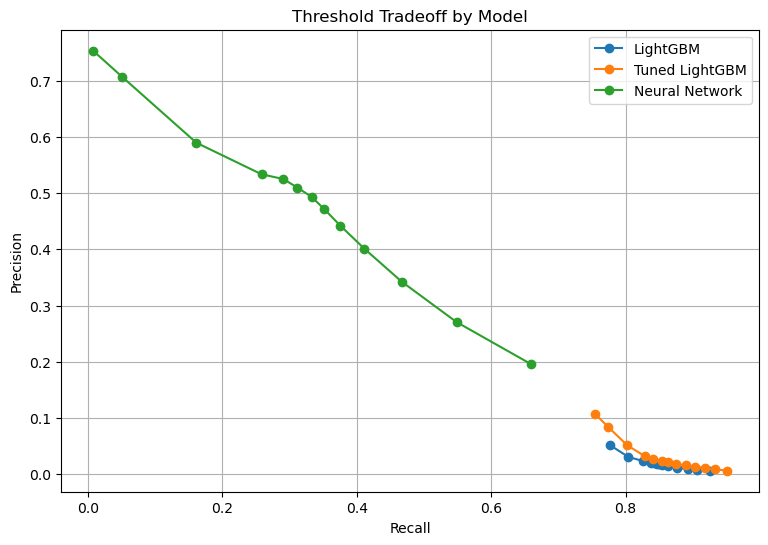

In [44]:
plt.figure(figsize=(9, 6))

for model_name in threshold_results["model"].unique():
    model_thresholds = threshold_results[threshold_results["model"] == model_name]
    plt.plot(
        model_thresholds["recall"],
        model_thresholds["precision"],
        marker="o",
        label=model_name
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Threshold Tradeoff by Model")
plt.legend()
plt.grid(True)
plt.show()

## 11. Oversampling experiment

I had also been given a suggestion trying oversampling because the target class is very imbalanced. This makes sense because serious delinquency cases are rare, and the model may not see enough positive examples during training.

I am using random oversampling instead of SMOTE. The reason is that the processed dataset includes one-hot encoded categorical features. SMOTE can create synthetic rows with fractional dummy variables, which are harder to interpret. Random oversampling is simpler because it duplicates existing minority-class examples in the training data.

The test set is not oversampled. Oversampling is only applied to the training data so that the final evaluation still reflects the real class balance.

In [45]:
from imblearn.over_sampling import RandomOverSampler

oversampler = RandomOverSampler(
    sampling_strategy=0.25,
    random_state=42
)

X_train_over, y_train_over = oversampler.fit_resample(X_train, y_train)

print("Original training shape:", X_train.shape)
print("Oversampled training shape:", X_train_over.shape)
print("Original positive rate:", y_train.mean())
print("Oversampled positive rate:", y_train_over.mean())

Original training shape: (10059227, 172)
Oversampled training shape: (12544275, 172)
Original positive rate: 0.002366682847499117
Oversampled positive rate: 0.2


### Oversampled logistic regression

I am first testing oversampling with logistic regression. This shows whether duplicating minority-class examples helps a simpler linear model identify more serious delinquency cases.

In [46]:
over_log_reg_model = LogisticRegression(
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

over_log_reg_model.fit(X_train_over, y_train_over)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [47]:
over_log_reg_metrics = evaluate_classifier(
    "Oversampled Logistic Regression",
    over_log_reg_model,
    X_train,
    y_train,
    X_test,
    y_test
)

model_results = model_results[
    ~model_results["model"].isin(["Oversampled Logistic Regression"])
].copy()

model_results = pd.concat(
    [
        model_results,
        pd.DataFrame([over_log_reg_metrics])
    ],
    ignore_index=True
)

display(model_results)

,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,train_roc_auc,test_roc_auc,train_pr_auc,test_pr_auc
0,Dummy Classifier,0.997633,0.997005,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.500000,0.002367,0.002995
1,Logistic Regression,0.893795,0.929170,0.017820,0.033887,0.810728,0.823290,0.034873,0.065094,0.929859,0.942658,0.197658,0.213268
2,LightGBM,0.859547,0.876879,0.013511,0.020066,0.810224,0.838456,0.026579,0.039194,0.888931,0.900956,0.036637,0.069581
3,XGBoost,0.896681,0.942048,0.018814,0.041130,0.833914,0.822343,0.036798,0.078342,0.946494,0.947248,0.320489,0.329854
4,Neural Network,0.997855,0.997102,0.624581,0.533576,0.234595,0.258226,0.341079,0.348024,0.953575,0.940716,0.341560,0.328794
5,Tuned LightGBM,0.898691,0.924858,0.020244,0.032173,0.882051,0.828301,0.039580,0.061941,0.967135,0.936616,0.337215,0.326187
6,Tuned XGBoost,0.904922,0.945279,0.020777,0.043522,0.849204,0.823290,0.040562,0.082673,0.956202,0.947820,0.339173,0.337111
7,Oversampled Logistic Regression,0.986071,0.984975,0.101692,0.132456,0.623640,0.723764,0.174869,0.223931,0.929438,0.942370,0.211105,0.223592


In [48]:
over_log_reg_scores = over_log_reg_model.predict_proba(X_test)[:, 1]
over_log_reg_test_pred = over_log_reg_model.predict(X_test)

over_log_reg_cm = confusion_matrix(y_test, over_log_reg_test_pred)

over_log_reg_cm_df = pd.DataFrame(
    over_log_reg_cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(over_log_reg_cm_df)
print(classification_report(y_test, over_log_reg_test_pred, zero_division=0))

,Predicted 0,Predicted 1
Actual 0,2423319,35008
Actual 1,2040,5345


              precision    recall  f1-score   support

           0       1.00      0.99      0.99   2458327
           1       0.13      0.72      0.22      7385

    accuracy                           0.98   2465712
   macro avg       0.57      0.85      0.61   2465712
weighted avg       1.00      0.98      0.99   2465712



### Oversampled LightGBM

I am also testing oversampling with LightGBM. Since oversampling already changes the class balance in the training data, I am not using `scale_pos_weight` in this version. This avoids correcting for imbalance twice.

In [49]:
over_lgbm_model = LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

over_lgbm_model.fit(X_train_over, y_train_over)

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, min_child_samples=50,
               n_estimators=300, n_jobs=-1, objective='binary', random_state=42,
               subsample=0.8, verbosity=-1)

In [50]:
over_lgbm_metrics = evaluate_classifier(
    "Oversampled LightGBM",
    over_lgbm_model,
    X_train,
    y_train,
    X_test,
    y_test
)

model_results = model_results[
    ~model_results["model"].isin(["Oversampled LightGBM"])
].copy()

model_results = pd.concat(
    [
        model_results,
        pd.DataFrame([over_lgbm_metrics])
    ],
    ignore_index=True
)

display(model_results)

,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,train_roc_auc,test_roc_auc,train_pr_auc,test_pr_auc
0,Dummy Classifier,0.997633,0.997005,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.500000,0.002367,0.002995
1,Logistic Regression,0.893795,0.929170,0.017820,0.033887,0.810728,0.823290,0.034873,0.065094,0.929859,0.942658,0.197658,0.213268
2,LightGBM,0.859547,0.876879,0.013511,0.020066,0.810224,0.838456,0.026579,0.039194,0.888931,0.900956,0.036637,0.069581
3,XGBoost,0.896681,0.942048,0.018814,0.041130,0.833914,0.822343,0.036798,0.078342,0.946494,0.947248,0.320489,0.329854
4,Neural Network,0.997855,0.997102,0.624581,0.533576,0.234595,0.258226,0.341079,0.348024,0.953575,0.940716,0.341560,0.328794
5,Tuned LightGBM,0.898691,0.924858,0.020244,0.032173,0.882051,0.828301,0.039580,0.061941,0.967135,0.936616,0.337215,0.326187
6,Tuned XGBoost,0.904922,0.945279,0.020777,0.043522,0.849204,0.823290,0.040562,0.082673,0.956202,0.947820,0.339173,0.337111
7,Oversampled Logistic Regression,0.986071,0.984975,0.101692,0.132456,0.623640,0.723764,0.174869,0.223931,0.929438,0.942370,0.211105,0.223592
8,Oversampled LightGBM,0.984810,0.982858,0.099880,0.120881,0.676272,0.753013,0.174054,0.208320,0.971851,0.948849,0.353152,0.339708


In [51]:
over_lgbm_scores = over_lgbm_model.predict_proba(X_test)[:, 1]
over_lgbm_test_pred = over_lgbm_model.predict(X_test)

over_lgbm_cm = confusion_matrix(y_test, over_lgbm_test_pred)

over_lgbm_cm_df = pd.DataFrame(
    over_lgbm_cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(over_lgbm_cm_df)
print(classification_report(y_test, over_lgbm_test_pred, zero_division=0))

,Predicted 0,Predicted 1
Actual 0,2417884,40443
Actual 1,1824,5561


              precision    recall  f1-score   support

           0       1.00      0.98      0.99   2458327
           1       0.12      0.75      0.21      7385

    accuracy                           0.98   2465712
   macro avg       0.56      0.87      0.60   2465712
weighted avg       1.00      0.98      0.99   2465712



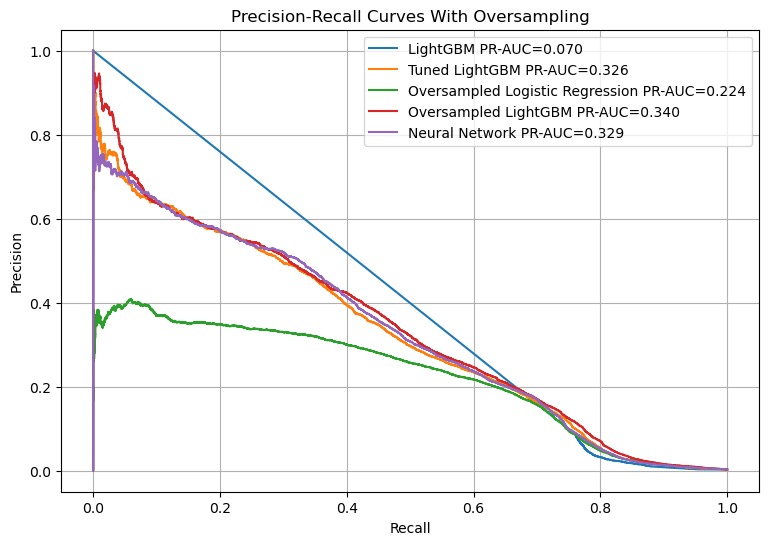

In [52]:
oversampling_score_sets = {
    "LightGBM": lgbm_scores,
    "Tuned LightGBM": tuned_lgbm_scores,
    "Oversampled Logistic Regression": over_log_reg_scores,
    "Oversampled LightGBM": over_lgbm_scores,
    "Neural Network": mlp_scores
}

plt.figure(figsize=(9, 6))

for model_name, scores in oversampling_score_sets.items():
    precision_values, recall_values, threshold_values = precision_recall_curve(y_test, scores)
    pr_auc_value = average_precision_score(y_test, scores)
    plt.plot(recall_values, precision_values, label=f"{model_name} PR-AUC={pr_auc_value:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves With Oversampling")
plt.legend()
plt.grid(True)
plt.show()

The oversampling experiment produced the best model in the notebook. Oversampled LightGBM has the highest test PR-AUC at about 0.340, and a far more practical default threshold than any of the class-weighted tree models. At the 0.50 cutoff it flags about 46,000 loan-months, just under 2% of the test set, and catches 5,561 of the 7,385 serious delinquency cases with precision around 12%.

This is a different outcome than my earlier sample run, where oversampling traded a little ranking quality for a better default cutoff. On the full panel it wins on both. I think capping the positive share at 20% of training rows is simply a gentler correction than a 420x class weight, and LightGBM responds much better to it.

Oversampling also improved logistic regression's default threshold, but its PR-AUC is still well behind the tree models, so it stays an interpretable reference rather than a real candidate.

## 12. Threshold tuning with oversampling

Since Oversampled LightGBM performed well at the default threshold, I am adding it to the threshold comparison. This helps compare the original LightGBM, tuned LightGBM, oversampled LightGBM, and the neural network under different cutoff choices.

This step is important because the best model depends on the business goal. If the goal is to catch as many risky loans as possible, a lower threshold may be better. If the goal is to keep the review list smaller, a higher threshold may be better.

In [53]:
threshold_results_updated = pd.concat(
    [
        evaluate_thresholds("LightGBM", y_test, lgbm_scores, thresholds_to_check),
        evaluate_thresholds("Tuned LightGBM", y_test, tuned_lgbm_scores, thresholds_to_check),
        evaluate_thresholds("Oversampled LightGBM", y_test, over_lgbm_scores, thresholds_to_check),
        evaluate_thresholds("Neural Network", y_test, mlp_scores, thresholds_to_check)
    ],
    ignore_index=True
)

display(threshold_results_updated)

,model,threshold,precision,recall,f1,true_positives,false_positives,false_negatives,true_negatives,flagged_loans,flag_rate
0,LightGBM,0.05,0.006026,0.925254,0.011975,6833,1127009,552,1331318,1133842,0.459844
1,LightGBM,0.10,0.007764,0.906297,0.015395,6693,855405,692,1602922,862098,0.349635
2,LightGBM,0.15,0.009116,0.892620,0.018048,6592,716532,793,1741795,723124,0.293272
3,LightGBM,0.20,0.010749,0.877183,0.021238,6478,596184,907,1862143,602662,0.244417
4,LightGBM,0.25,0.014765,0.863778,0.029033,6379,425661,1006,2032666,432040,0.175219
5,LightGBM,0.30,0.016675,0.854299,0.032712,6309,372038,1076,2086289,378347,0.153443
6,LightGBM,0.35,0.017543,0.850508,0.034378,6281,351745,1104,2106582,358026,0.145202
7,LightGBM,0.40,0.018215,0.847123,0.035663,6256,337194,1129,2121133,343450,0.139290
8,LightGBM,0.45,0.018984,0.842519,0.037132,6222,321521,1163,2136806,327743,0.132920
9,LightGBM,0.50,0.020066,0.838456,0.039194,6192,302389,1193,2155938,308581,0.125149


In [54]:
best_f1_thresholds_updated = (
    threshold_results_updated
    .sort_values(["model", "f1"], ascending=[True, False])
    .groupby("model")
    .head(1)
    .reset_index(drop=True)
)

display(best_f1_thresholds_updated)

,model,threshold,precision,recall,f1,true_positives,false_positives,false_negatives,true_negatives,flagged_loans,flag_rate
0,LightGBM,0.8,0.051810,0.776574,0.097140,5735,104957,1650,2353370,110692,0.044893
1,Neural Network,0.2,0.401003,0.411374,0.406123,3038,4538,4347,2453789,7576,0.003073
2,Oversampled LightGBM,0.8,0.180789,0.687881,0.286326,5080,23019,2305,2435308,28099,0.011396
3,Tuned LightGBM,0.8,0.106780,0.754909,0.187096,5575,46635,1810,2411692,52210,0.021174


In [55]:
target_recall_thresholds_updated = (
    threshold_results_updated[threshold_results_updated["recall"] >= 0.70]
    .sort_values(["model", "precision"], ascending=[True, False])
    .groupby("model")
    .head(1)
    .reset_index(drop=True)
)

display(target_recall_thresholds_updated)

,model,threshold,precision,recall,f1,true_positives,false_positives,false_negatives,true_negatives,flagged_loans,flag_rate
0,LightGBM,0.8,0.051810,0.776574,0.097140,5735,104957,1650,2353370,110692,0.044893
1,Oversampled LightGBM,0.7,0.157246,0.713879,0.257724,5272,28255,2113,2430072,33527,0.013597
2,Tuned LightGBM,0.8,0.106780,0.754909,0.187096,5575,46635,1810,2411692,52210,0.021174


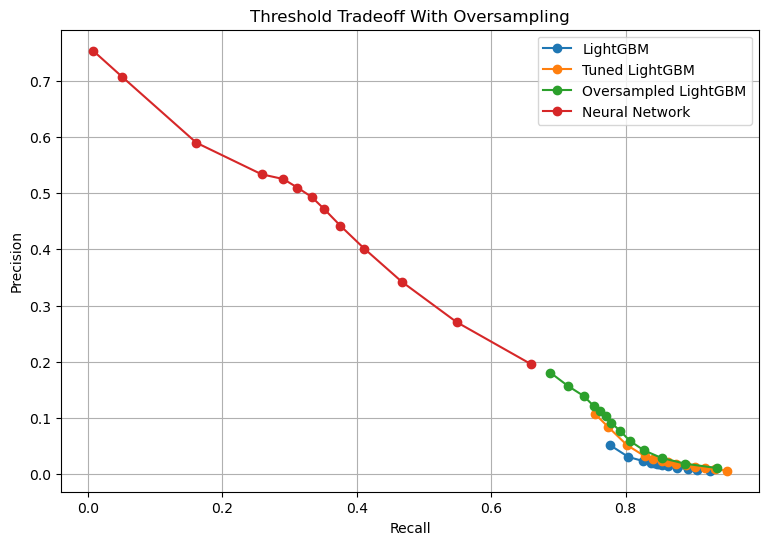

In [56]:
plt.figure(figsize=(9, 6))

for model_name in threshold_results_updated["model"].unique():
    model_thresholds = threshold_results_updated[
        threshold_results_updated["model"] == model_name
    ]

    plt.plot(
        model_thresholds["recall"],
        model_thresholds["precision"],
        marker="o",
        label=model_name
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Threshold Tradeoff With Oversampling")
plt.legend()
plt.grid(True)
plt.show()

The updated threshold table keeps Oversampled LightGBM as the strongest practical choice. At the default 0.50 cutoff it catches 5,561 of the 7,385 serious delinquency cases while flagging about 1.9% of the test set. Raising its threshold to 0.70 trades some recall, down to about 71%, for better precision around 16% and a review list of about 1.4% of rows. So there is room to tighten the list without giving up much coverage.

The neural network still has the single best F1 score, 0.41 at a 0.20 threshold, but it only catches about 41% of the serious delinquency cases there. Since this project is focused on early warning, that recall is too low for the final model.

Tuned LightGBM can reach similar recall at a 0.80 cutoff, but it needs a larger review list with lower precision, and the class-weighted LightGBM needs more than twice as many flags for the same coverage. The oversampled version gives the same coverage with the smallest list.

## 12.5 Picking the final threshold on validation data

One weakness in the threshold sections above is that I compared cutoffs directly on the test set. If I also pick the final threshold from those tables, the test set is no longer a clean holdout, because it helped choose the final setup.

To fix that, I am refitting the oversampled LightGBM on the earlier 80% of training months, picking the threshold on the validation months, and only then applying that threshold to the test set. The selection rule matches the project goal: keep recall at or above 0.70, then take the cutoff with the best precision. If no cutoff reaches that recall, I fall back to the best validation F1.

In [57]:
oversampler_valid = RandomOverSampler(
    sampling_strategy=0.25,
    random_state=42
)

X_tune_train_over, y_tune_train_over = oversampler_valid.fit_resample(X_tune_train, y_tune_train)

valid_over_lgbm_model = LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

valid_over_lgbm_model.fit(X_tune_train_over, y_tune_train_over)
valid_over_scores = valid_over_lgbm_model.predict_proba(X_tune_valid)[:, 1]

print("Validation rows:", X_tune_valid.shape[0])
print("Validation positives:", int(y_tune_valid.sum()))

Validation rows: 2011846
Validation positives: 5276


In [58]:
validation_threshold_results = evaluate_thresholds(
    "Oversampled LightGBM (validation)",
    y_tune_valid,
    valid_over_scores,
    thresholds_to_check
)

display(validation_threshold_results)

recall_floor_rows = validation_threshold_results[validation_threshold_results["recall"] >= 0.70]

if len(recall_floor_rows) > 0:
    selected_row = recall_floor_rows.sort_values("precision", ascending=False).iloc[0]
    selection_rule = "best precision with recall >= 0.70"
else:
    selected_row = validation_threshold_results.sort_values("f1", ascending=False).iloc[0]
    selection_rule = "best F1 (no cutoff reached recall 0.70)"

selected_threshold = float(selected_row["threshold"])

print("Selection rule:", selection_rule)
print("Selected threshold:", selected_threshold)
print("Validation precision at selected threshold:", round(float(selected_row["precision"]), 4))
print("Validation recall at selected threshold:", round(float(selected_row["recall"]), 4))

,model,threshold,precision,recall,f1,true_positives,false_positives,false_negatives,true_negatives,flagged_loans,flag_rate
0,Oversampled LightGBM (validation),0.05,0.009307,0.946171,0.018432,4992,531384,284,1475186,536376,0.266609
1,Oversampled LightGBM (validation),0.10,0.016458,0.897839,0.032324,4737,283081,539,1723489,287818,0.143062
2,Oversampled LightGBM (validation),0.15,0.025996,0.858226,0.050463,4528,169654,748,1836916,174182,0.086578
3,Oversampled LightGBM (validation),0.20,0.040064,0.831122,0.076442,4385,105066,891,1901504,109451,0.054403
4,Oversampled LightGBM (validation),0.25,0.057375,0.793404,0.107011,4186,68773,1090,1937797,72959,0.036265
5,Oversampled LightGBM (validation),0.30,0.077209,0.778810,0.140491,4109,49110,1167,1957460,53219,0.026453
6,Oversampled LightGBM (validation),0.35,0.093376,0.767627,0.166499,4050,39323,1226,1967247,43373,0.021559
7,Oversampled LightGBM (validation),0.40,0.105201,0.759856,0.184815,4009,34099,1267,1972471,38108,0.018942
8,Oversampled LightGBM (validation),0.45,0.113770,0.753412,0.197687,3975,30964,1301,1975606,34939,0.017367
9,Oversampled LightGBM (validation),0.50,0.121286,0.747346,0.208702,3943,28567,1333,1978003,32510,0.016159


Selection rule: best precision with recall >= 0.70
Selected threshold: 0.7
Validation precision at selected threshold: 0.1581
Validation recall at selected threshold: 0.7151


In [59]:
test_at_selected = evaluate_thresholds(
    "Oversampled LightGBM (test)",
    y_test,
    over_lgbm_scores,
    [selected_threshold, 0.50]
)

display(test_at_selected)

,model,threshold,precision,recall,f1,true_positives,false_positives,false_negatives,true_negatives,flagged_loans,flag_rate
0,Oversampled LightGBM (test),0.7,0.157246,0.713879,0.257724,5272,28255,2113,2430072,33527,0.013597
1,Oversampled LightGBM (test),0.5,0.120881,0.753013,0.208320,5561,40443,1824,2417884,46004,0.018657


The selection rule landed on a threshold of 0.70. Validation said that cutoff should give about 15.8% precision at 71.5% recall, and the test set came in at 15.7% precision and 71.4% recall, almost exactly what validation predicted. Compared with the default 0.50, the chosen cutoff gives up about 4 points of recall but shrinks the review list from about 46,000 rows to about 33,500. I am using this validation-chosen threshold for the final model.

## 12.6 Loan-level results by scoring month

All of the metrics so far count loan-month rows, so a loan that stays risky for several months is counted more than once. A lender does not review rows, they review loans. Each loan appears once per reporting month in the panel, so grouping the test set by month shows what the model's review list would look like in practice: every active loan gets scored once that month, and the flagged ones go to review.

The table below applies the final model and the validation-chosen threshold to each test month separately.

In [60]:
test_meta = pd.read_csv(PREPROCESSING_DIR / "test_meta.csv", parse_dates=["monthly_reporting_period"])

assert len(test_meta) == X_test.shape[0]
assert test_meta.duplicated(subset=["loan_identifier", "monthly_reporting_period"]).sum() == 0

loan_month_eval = test_meta.copy()
loan_month_eval["actual"] = y_test.values
loan_month_eval["flagged"] = (over_lgbm_scores >= selected_threshold).astype(int)
loan_month_eval["caught"] = ((loan_month_eval["flagged"] == 1) & (loan_month_eval["actual"] == 1)).astype(int)

monthly_loan_summary = (
    loan_month_eval
    .groupby(loan_month_eval["monthly_reporting_period"].dt.strftime("%Y-%m"))
    .agg(
        loans_scored=("actual", "size"),
        actual_positives=("actual", "sum"),
        loans_flagged=("flagged", "sum"),
        positives_caught=("caught", "sum")
    )
    .reset_index()
    .rename(columns={"monthly_reporting_period": "scoring_month"})
)

monthly_loan_summary["flag_rate"] = monthly_loan_summary["loans_flagged"] / monthly_loan_summary["loans_scored"]
monthly_loan_summary["precision"] = monthly_loan_summary["positives_caught"] / monthly_loan_summary["loans_flagged"]
monthly_loan_summary["recall"] = monthly_loan_summary["positives_caught"] / monthly_loan_summary["actual_positives"]

display(monthly_loan_summary)

,scoring_month,loans_scored,actual_positives,loans_flagged,positives_caught,flag_rate,precision,recall
0,2024-08,228101,726,3133,505,0.013735,0.161187,0.695592
1,2024-09,227338,707,3276,497,0.014410,0.151709,0.702970
2,2024-10,226469,717,3054,522,0.013485,0.170923,0.728033
3,2024-11,225715,686,3088,497,0.013681,0.160946,0.724490
4,2024-12,224883,635,3099,458,0.013780,0.147790,0.721260
5,2025-01,224229,611,2891,432,0.012893,0.149429,0.707038
6,2025-02,223591,612,2998,454,0.013408,0.151434,0.741830
7,2025-03,222788,651,2931,469,0.013156,0.160014,0.720430
8,2025-04,221856,662,2944,463,0.013270,0.157269,0.699396
9,2025-05,220875,680,2999,478,0.013578,0.159386,0.702941


Looked at this way, the model holds up month to month. Each test month it scores roughly 220,000 to 228,000 active loans, flags about 2,900 to 3,300 of them, and catches 70% to 74% of that month's serious delinquency cases at 15% to 17% precision. There are no bad months hiding inside the overall averages, which is what I would want from an early-warning screen that runs on a monthly cycle.

## 12.7 Calibration check

Oversampling deliberately changes the class balance the model trains on, so the predicted scores are not honest probabilities. That is fine for ranking and for threshold-based review lists, but it would be a problem if anyone read a score of 0.60 as a 60% chance of serious delinquency.

This section checks how distorted the scores are, and shows that a simple isotonic regression can map them back to real probabilities. To keep this clean, the calibration test uses the refit model from section 12.5, so the calibrator is fit on validation months the model never trained on, and then judged on the test set.

In [61]:
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss

refit_test_scores = valid_over_lgbm_model.predict_proba(X_test)[:, 1]

iso_calibrator = IsotonicRegression(out_of_bounds="clip")
iso_calibrator.fit(valid_over_scores, y_tune_valid)
calibrated_test_scores = iso_calibrator.transform(refit_test_scores)

print("Test base rate:", round(float(y_test.mean()), 5))
print("Mean raw score:", round(float(refit_test_scores.mean()), 5))
print("Mean calibrated score:", round(float(calibrated_test_scores.mean()), 5))
print("Brier score raw:", round(brier_score_loss(y_test, refit_test_scores), 6))
print("Brier score calibrated:", round(brier_score_loss(y_test, calibrated_test_scores), 6))
print("PR-AUC raw:", round(average_precision_score(y_test, refit_test_scores), 4))
print("PR-AUC calibrated:", round(average_precision_score(y_test, calibrated_test_scores), 4))

Test base rate: 0.003
Mean raw score: 0.05347
Mean calibrated score: 0.00266
Brier score raw: 0.015247
Brier score calibrated: 0.002376


PR-AUC raw: 0.3058


PR-AUC calibrated: 0.2975


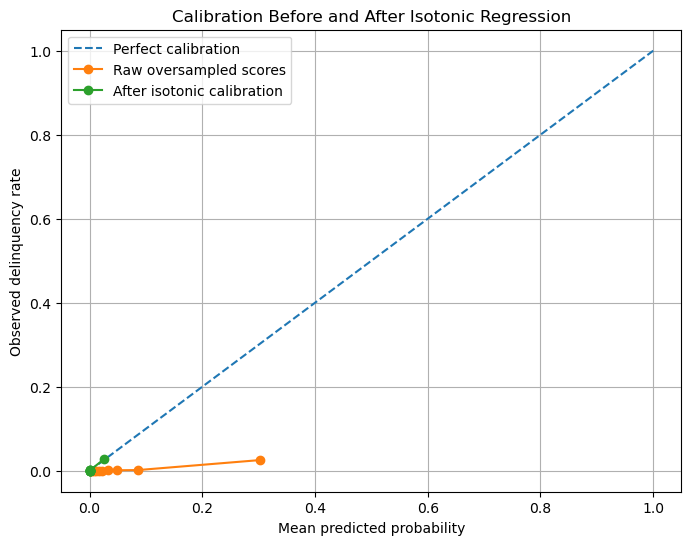

In [62]:
prob_true_raw, prob_pred_raw = calibration_curve(y_test, refit_test_scores, n_bins=10, strategy="quantile")
prob_true_cal, prob_pred_cal = calibration_curve(y_test, calibrated_test_scores, n_bins=10, strategy="quantile")

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.plot(prob_pred_raw, prob_true_raw, marker="o", label="Raw oversampled scores")
plt.plot(prob_pred_cal, prob_true_cal, marker="o", label="After isotonic calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed delinquency rate")
plt.title("Calibration Before and After Isotonic Regression")
plt.legend()
plt.grid(True)
plt.show()

The raw scores are heavily inflated, as expected. The mean raw score is about 0.053 against a true base rate of about 0.003, and the calibration curve sits far above the diagonal. After isotonic calibration the mean score lands almost exactly on the base rate, the Brier score improves from 0.0152 to 0.0024, and the points sit close to the diagonal. PR-AUC barely moves, going from 0.306 to 0.298, a small dip that comes from ties in the isotonic step function. So calibration fixes the probabilities without giving up the ranking. For this project the uncalibrated scores are fine, since the model only feeds a review list. If the scores ever fed expected-loss math, this calibration step is the one I would productionize.

## 13. Final model selection

The final model I selected is Oversampled LightGBM with a classification threshold of 0.70, chosen on the validation months in section 12.5 using the recall-first rule.

This choice is easier to defend than it was on the earlier sample run. The oversampled model is now the best ranking model with the highest test PR-AUC, and the threshold was picked before the test set was touched. Validation also predicted the test behavior almost exactly, which gives me more confidence that the cutoff will hold up on new months.

The goal is not just to create the highest accuracy model. The goal is to identify loans that are at risk of becoming seriously delinquent within the next six months, and to do it with a review list that a lender could realistically work through.

In [63]:
final_model = over_lgbm_model
final_model_name = "Oversampled LightGBM"
final_threshold = float(selected_threshold)
final_scores = over_lgbm_scores
final_predictions = (final_scores >= final_threshold).astype(int)

final_cm = confusion_matrix(y_test, final_predictions)

final_cm_df = pd.DataFrame(
    final_cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(final_cm_df)
print(classification_report(y_test, final_predictions, zero_division=0))

,Predicted 0,Predicted 1
Actual 0,2430072,28255
Actual 1,2113,5272


              precision    recall  f1-score   support

           0       1.00      0.99      0.99   2458327
           1       0.16      0.71      0.26      7385

    accuracy                           0.99   2465712
   macro avg       0.58      0.85      0.63   2465712
weighted avg       1.00      0.99      0.99   2465712



In [64]:
final_metrics = {
    "final_model": final_model_name,
    "threshold": final_threshold,
    "accuracy": accuracy_score(y_test, final_predictions),
    "precision": precision_score(y_test, final_predictions, zero_division=0),
    "recall": recall_score(y_test, final_predictions, zero_division=0),
    "f1": f1_score(y_test, final_predictions, zero_division=0),
    "roc_auc": roc_auc_score(y_test, final_scores),
    "pr_auc": average_precision_score(y_test, final_scores),
    "true_positives": final_cm[1, 1],
    "false_positives": final_cm[0, 1],
    "false_negatives": final_cm[1, 0],
    "true_negatives": final_cm[0, 0],
    "flagged_loans": int(final_predictions.sum()),
    "flag_rate": final_predictions.mean()
}

final_metrics_df = pd.DataFrame([final_metrics])
display(final_metrics_df)

,final_model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,true_positives,false_positives,false_negatives,true_negatives,flagged_loans,flag_rate
0,Oversampled LightGBM,0.7,0.987684,0.157246,0.713879,0.257724,0.948849,0.339708,5272,28255,2113,2430072,33527,0.013597


In [65]:
final_model_comparison = model_results[
    [
        "model",
        "test_accuracy",
        "test_precision",
        "test_recall",
        "test_f1",
        "test_roc_auc",
        "test_pr_auc"
    ]
].copy()

final_model_comparison = final_model_comparison.sort_values("test_pr_auc", ascending=False)

display(final_model_comparison)

,model,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc
8,Oversampled LightGBM,0.982858,0.120881,0.753013,0.208320,0.948849,0.339708
6,Tuned XGBoost,0.945279,0.043522,0.823290,0.082673,0.947820,0.337111
3,XGBoost,0.942048,0.041130,0.822343,0.078342,0.947248,0.329854
4,Neural Network,0.997102,0.533576,0.258226,0.348024,0.940716,0.328794
5,Tuned LightGBM,0.924858,0.032173,0.828301,0.061941,0.936616,0.326187
7,Oversampled Logistic Regression,0.984975,0.132456,0.723764,0.223931,0.942370,0.223592
1,Logistic Regression,0.929170,0.033887,0.823290,0.065094,0.942658,0.213268
2,LightGBM,0.876879,0.020066,0.838456,0.039194,0.900956,0.069581
0,Dummy Classifier,0.997005,0.000000,0.000000,0.000000,0.500000,0.002995


## 14. Feature importance

After selecting the final model, I want to look at which features were most important to the Oversampled LightGBM model.

This does not prove that these features cause delinquency, but it helps explain what the model relied on most when making predictions. Since this is a tree-based model, I can use the model's built-in feature importance values as a simple interpretation step.

One thing to keep in mind when reading this table: LightGBM's default importance counts how many times a feature was used in a split. Continuous fields like credit score, DTI, and the balance fields offer many possible split points, so they naturally collect more splits than binary flags. The delinquency-status flags that looked strongest in EDA are still in the model, they just spend their value in a small number of high-impact splits instead of many small ones. A gain-based importance or SHAP values would be a fairer view, and that would be a reasonable next step.

In [66]:
if "feature_name" in feature_names.columns:
    processed_feature_names = feature_names["feature_name"].tolist()
elif "feature" in feature_names.columns:
    processed_feature_names = feature_names["feature"].tolist()
else:
    processed_feature_names = feature_names.iloc[:, 0].tolist()

feature_importance_df = pd.DataFrame({
    "feature": processed_feature_names,
    "importance": final_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

display(feature_importance_df.head(25))

,feature,importance
0,borrower_credit_score_at_origination,868
1,dti,558
2,original_upb,504
3,current_actual_upb,459
4,co_borrower_credit_score_at_origination,442
5,original_interest_rate,427
6,original_ltv,397
7,original_cltv,393
8,total_principal_current,346
9,remaining_months_to_maturity,253


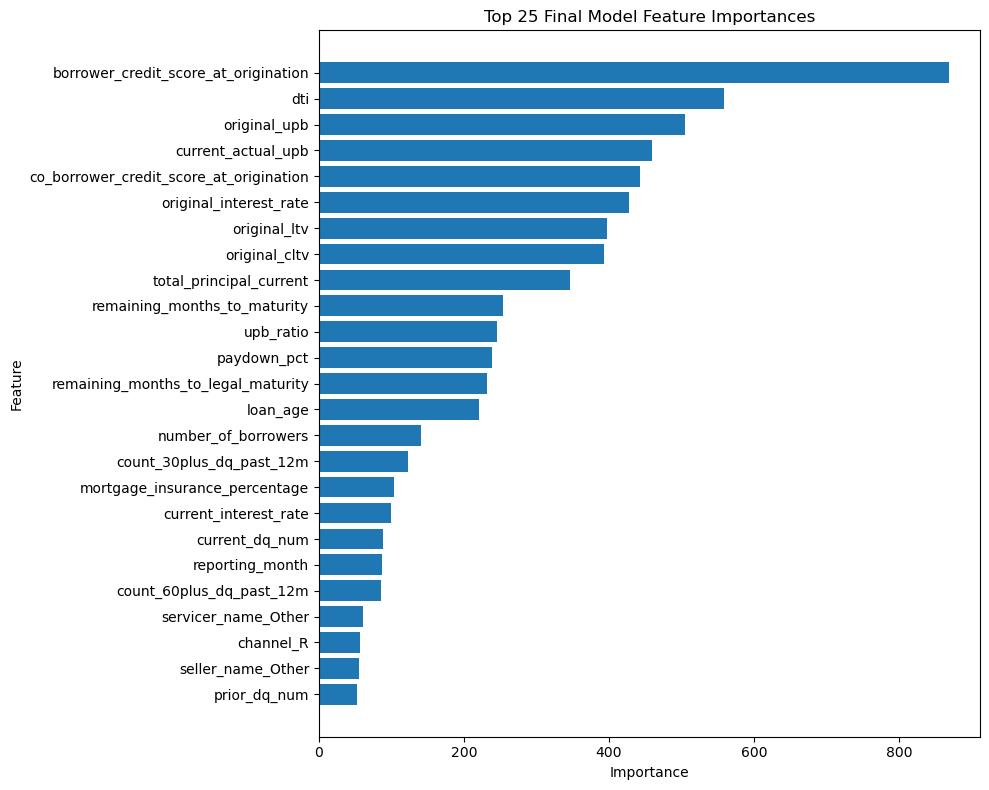

In [67]:
top_feature_importance = feature_importance_df.head(25).sort_values("importance")

plt.figure(figsize=(10, 8))
plt.barh(top_feature_importance["feature"], top_feature_importance["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 25 Final Model Feature Importances")
plt.tight_layout()
plt.show()

## 15. Save final model outputs

The last step is to save the final model and the key outputs from the modeling notebook. These files can be used later for the final report, model metrics file, or GitHub repository.

I am saving the model, the selected threshold, the final metrics, the model comparison table, and the feature importance table.

In [68]:
final_artifacts = {
    "model_name": final_model_name,
    "threshold": final_threshold,
    "model": final_model
}

joblib.dump(final_artifacts, MODEL_OUTPUT_DIR / "final_oversampled_lgbm_model.joblib")

final_metrics_df.to_csv(MODEL_OUTPUT_DIR / "final_model_metrics.csv", index=False)
final_model_comparison.to_csv(MODEL_OUTPUT_DIR / "model_comparison.csv", index=False)
feature_importance_df.to_csv(MODEL_OUTPUT_DIR / "feature_importance.csv", index=False)

print("Saved final model to:", MODEL_OUTPUT_DIR / "final_oversampled_lgbm_model.joblib")
print("Saved final metrics to:", MODEL_OUTPUT_DIR / "final_model_metrics.csv")
print("Saved model comparison to:", MODEL_OUTPUT_DIR / "model_comparison.csv")
print("Saved feature importance to:", MODEL_OUTPUT_DIR / "feature_importance.csv")

Saved final model to: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\models\2021q1_q2_sample10pct\final_oversampled_lgbm_model.joblib
Saved final metrics to: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\models\2021q1_q2_sample10pct\final_model_metrics.csv
Saved model comparison to: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\models\2021q1_q2_sample10pct\model_comparison.csv
Saved feature importance to: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\models\2021q1_q2_sample10pct\feature_importance.csv


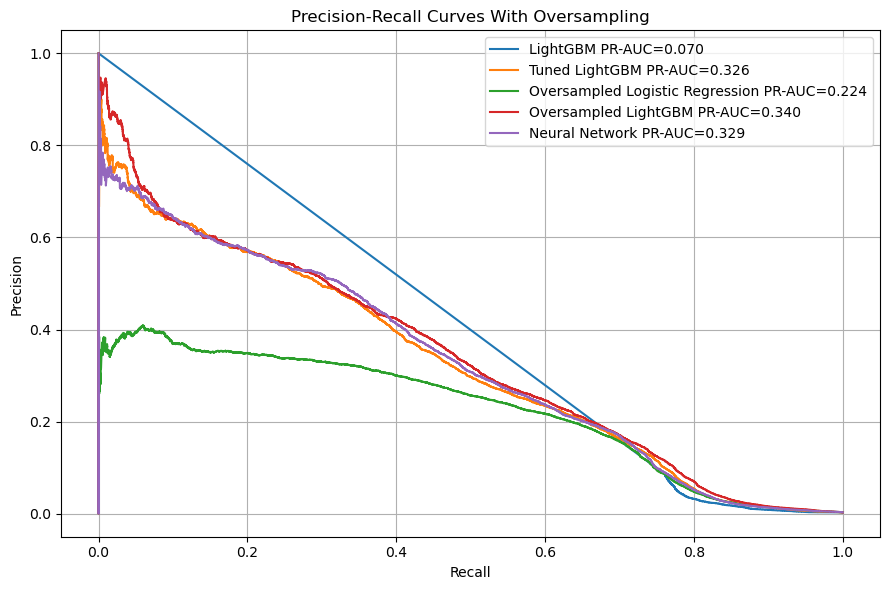

In [69]:
plt.figure(figsize=(9, 6))

for model_name, scores in oversampling_score_sets.items():
    precision_values, recall_values, threshold_values = precision_recall_curve(y_test, scores)
    pr_auc_value = average_precision_score(y_test, scores)
    plt.plot(recall_values, precision_values, label=f"{model_name} PR-AUC={pr_auc_value:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves With Oversampling")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "precision_recall_curves_with_oversampling.png", dpi=300)
plt.show()

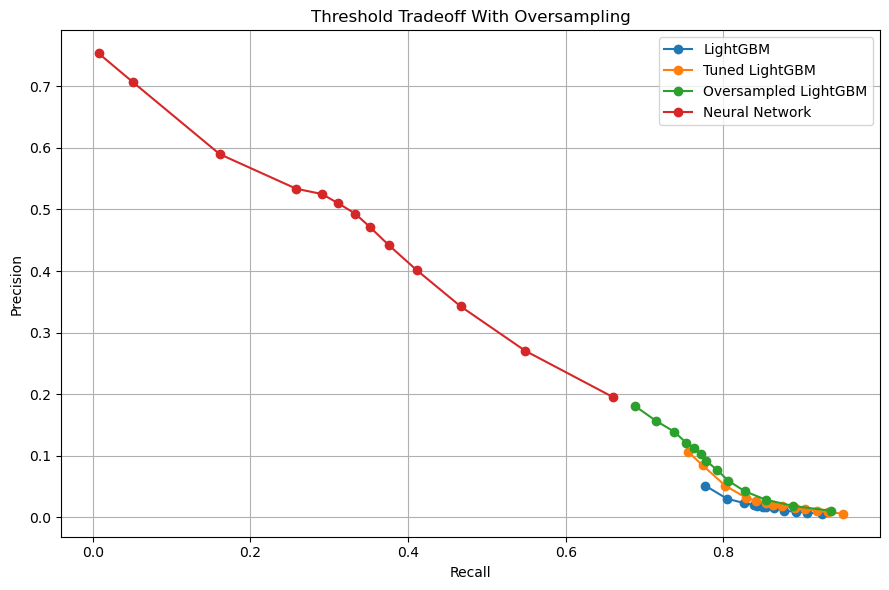

In [70]:
plt.figure(figsize=(9, 6))

for model_name in threshold_results_updated["model"].unique():
    model_thresholds = threshold_results_updated[
        threshold_results_updated["model"] == model_name
    ]

    plt.plot(
        model_thresholds["recall"],
        model_thresholds["precision"],
        marker="o",
        label=model_name
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Threshold Tradeoff With Oversampling")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "threshold_tradeoff_with_oversampling.png", dpi=300)
plt.show()

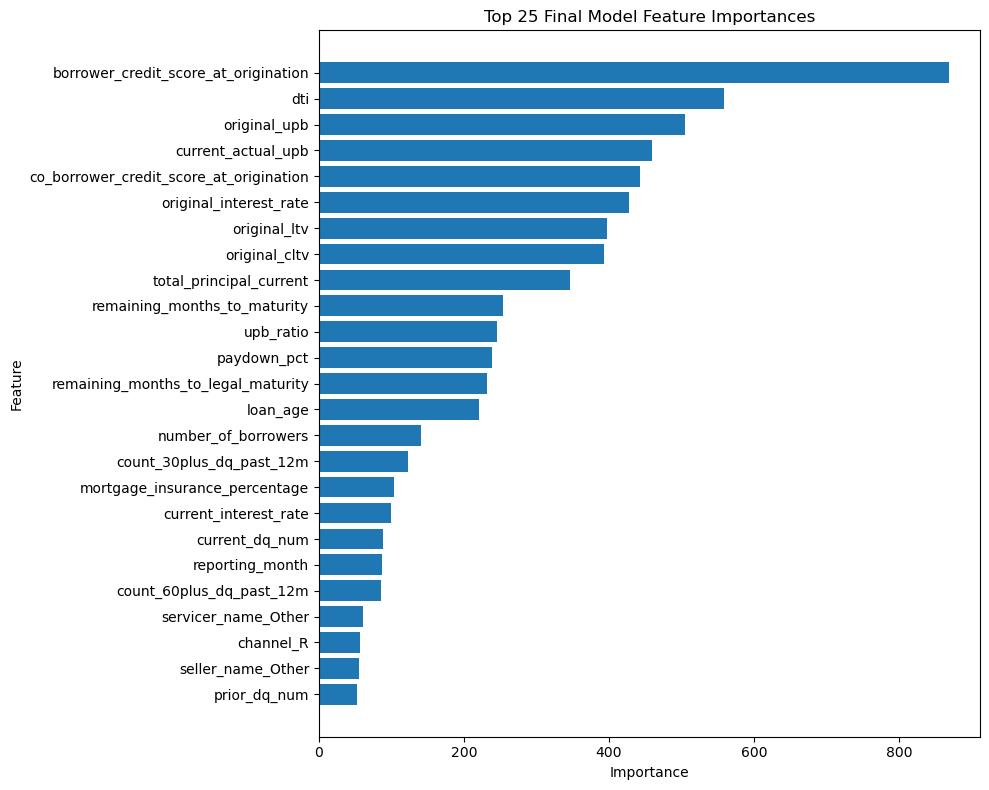

In [71]:
top_feature_importance = feature_importance_df.head(25).sort_values("importance")

plt.figure(figsize=(10, 8))
plt.barh(top_feature_importance["feature"], top_feature_importance["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 25 Final Model Feature Importances")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "final_model_feature_importance.png", dpi=300)
plt.show()

## 16. Modeling summary

The final model selected for this project is Oversampled LightGBM with a threshold of 0.70, chosen on validation months before the test set was touched. This model was selected because it had the highest test PR-AUC and gave the best practical balance between recall, precision, and review list size.

At that threshold the final model identified 5,272 of the 7,385 serious delinquency cases in the test set, which is about 71% recall, while flagging 33,527 loan-month rows, about 1.4% of the test set. The month-by-month view in section 12.6 shows the same result in practical terms: each test month the model scores roughly 220,000 to 228,000 active loans, flags about 3,000 of them, and catches 70% to 74% of that month's serious delinquency cases.

The model should not be treated as a final decision-maker. It is better used to prioritize loans for closer monitoring or additional review. The predicted scores also should not be read as probabilities without the calibration step from section 12.7, since oversampling shifts them upward by design. With isotonic calibration the scores line up with observed delinquency rates, so that piece is ready if the scores ever need to feed expected-loss math instead of a review list.